In [ ]:
import os
OPENPOSE_PATH="./openpose/"
HOME_PATH='./'

In [ ]:
!echo $HOME_PATH
!echo $OPENPOSE_PATH
!python --version

./
./openpose/
Python 3.10.12


Install OpenPose

In [ ]:
#@title
!pip install ffmpeg-python
from os.path import exists, join, basename, splitext

def show_local_mp4_video(file_name, width=640, height=480):
  import io
  import base64
  from IPython.display import HTML
  video_encoded = base64.b64encode(io.open(file_name, 'rb').read())
  return HTML(data='''<video width="{0}" height="{1}" alt="test" controls>
                        <source src="data:video/mp4;base64,{2}" type="video/mp4" />
                      </video>'''.format(width, height, video_encoded.decode('ascii')))


# install new CMake because of CUDA10
!wget -q https://cmake.org/files/v3.17/cmake-3.17.2-Linux-x86_64.tar.gz
!tar xfz cmake-3.17.2-Linux-x86_64.tar.gz --strip-components=1 -C /usr/local

# install system dependencies
!apt-get -qq install -y libatlas-base-dev libprotobuf-dev libleveldb-dev libsnappy-dev libhdf5-serial-dev protobuf-compiler libgflags-dev libgoogle-glog-dev liblmdb-dev opencl-headers ocl-icd-opencl-dev libviennacl-dev

git_repo_url = 'https://github.com/CMU-Perceptual-Computing-Lab/openpose.git'
project_name = splitext(basename(git_repo_url))[0]
!rm -rf openpose
# clone openpose
!git clone -q --depth 1 $git_repo_url
# fix CMakeLists.txt
!sed -i 's/execute_process(COMMAND git checkout --recursive master WORKING_DIRECTORY ${CMAKE_SOURCE_DIR}\/3rdparty\/caffe)/execute_process(COMMAND git checkout f019d0dfe86f49d1140961f8c7dec22130c83154 WORKING_DIRECTORY ${CMAKE_SOURCE_DIR}\/3rdparty\/caffe)/g' openpose/CMakeLists.txt
!cd openpose && git submodule update --init --recursive --remote


Selecting previously unselected package liblmdb0:amd64.
(Reading database ... 121753 files and directories currently installed.)
Preparing to unpack .../00-liblmdb0_0.9.24-1build2_amd64.deb ...
Unpacking liblmdb0:amd64 (0.9.24-1build2) ...
Selecting previously unselected package libgflags2.2.
Preparing to unpack .../01-libgflags2.2_2.2.2-2_amd64.deb ...
Unpacking libgflags2.2 (2.2.2-2) ...
Selecting previously unselected package libgflags-dev.
Preparing to unpack .../02-libgflags-dev_2.2.2-2_amd64.deb ...
Unpacking libgflags-dev (2.2.2-2) ...
Selecting previously unselected package libgoogle-glog0v5.
Preparing to unpack .../03-libgoogle-glog0v5_0.5.0+really0.4.0-2_amd64.deb ...
Unpacking libgoogle-glog0v5 (0.5.0+really0.4.0-2) ...
Selecting previously unselected package libunwind-dev:amd64.
Preparing to unpack .../04-libunwind-dev_1.3.2-2build2.1_amd64.deb ...
Unpacking libunwind-dev:amd64 (1.3.2-2build2.1) ...
Selecting previously unselected package libgoogle-glog-dev.
Preparing to un

**Get model**

In [ ]:
!pip install gdown

!gdown --id 1xvOnHp5l0xA17O1HREBFs53A6KapdSvA -O models.zip

#!wget 'https://drive.google.com/uc?export=download&id=1xvOnHp5l0xA17O1HREBFs53A6KapdSvA' -O models.zip

!apt-get install unzip

!unzip -o models.zip -d openpose


/usr/local/lib/python3.10/dist-packages/gdown/cli.py:138: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1xvOnHp5l0xA17O1HREBFs53A6KapdSvA
From (redirected): https://drive.google.com/uc?id=1xvOnHp5l0xA17O1HREBFs53A6KapdSvA&confirm=t&uuid=3d00a696-0778-4f78-ac23-9ac17978e4f6
To: /content/models.zip
100% 2.58G/2.58G [00:30<00:00, 85.4MB/s]
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unzip is already the newest version (6.0-26ubuntu3.2).
0 upgraded, 0 newly installed, 0 to remove and 45 not upgraded.
Archive:  models.zip
 extracting: openpose/models/pose/coco/pose_iter_440000.caffemodel  
 extracting: openpose/models/pose/coco/main.html  
 extracting: openpose/models/pose/mpi/pose_iter_160000.caffemodel  
 extracting: openpose/models/pose/body_25/pose_iter_584000.ca

In [ ]:
# use 'sed' to comment out the line in the OpenPose repo that downloads the model from the failed link
! sed -i 's/executeShInItsFolder "getModels.sh"/# executeShInItsFolder "getModels.sh"/g' ./openpose/scripts/ubuntu/install_openpose_JetsonTX2_JetPack3.1.sh
! sed -i 's/executeShInItsFolder "getModels.sh"/# executeShInItsFolder "getModels.sh"/g' ./openpose/scripts/ubuntu/install_openpose_JetsonTX2_JetPack3.3.sh
! sed -i 's/download_model("BODY_25"/# download_model("BODY_25"/g' ./openpose/CMakeLists.txt
! sed -i 's/78287B57CF85FA89C03F1393D368E5B7/# 78287B57CF85FA89C03F1393D368E5B7/g' ./openpose/CMakeLists.txt
! sed -i 's/download_model("body (COCO)"/# download_model("body (COCO)"/g' ./openpose/CMakeLists.txt
! sed -i 's/5156d31f670511fce9b4e28b403f2939/# 5156d31f670511fce9b4e28b403f2939/g' ./openpose/CMakeLists.txt
! sed -i 's/download_model("body (MPI)"/# download_model("body (MPI)"/g' ./openpose/CMakeLists.txt
! sed -i 's/2ca0990c7562bd7ae03f3f54afa96e00/# 2ca0990c7562bd7ae03f3f54afa96e00/g' ./openpose/CMakeLists.txt
! sed -i 's/download_model("face"/# download_model("face"/g' ./openpose/CMakeLists.txt
! sed -i 's/e747180d728fa4e4418c465828384333/# e747180d728fa4e4418c465828384333/g' ./openpose/CMakeLists.txt
! sed -i 's/download_model("hand"/# download_model("hand"/g' ./openpose/CMakeLists.txt
! sed -i 's/a82cfc3fea7c62f159e11bd3674c1531/# a82cfc3fea7c62f159e11bd3674c1531/g' ./openpose/CMakeLists.txt

In [ ]:
#show list of all files and directories in openpose (need for subsequent steps)
! ls -lha /usr/lib/x86_64-linux-gnu

total 5.6G
drwxr-xr-x  1 root root  4.0K Mar 31 02:13 .
drwxr-xr-x  1 root root  4.0K Mar 28 22:57 ..
drwxr-xr-x  2 root root  4.0K Mar 28 22:55 atlas
drwxr-xr-x  1 root root  4.0K Mar 28 22:55 audit
drwxr-xr-x  2 root root  4.0K Mar 28 22:56 avahi
drwxr-xr-x  2 root root  4.0K Nov 10 05:08 bfd-plugins
drwxr-xr-x  2 root root  4.0K Mar 28 22:55 blas
drwxr-xr-x  2 root root  4.0K Mar 28 22:56 caca
drwxr-xr-x  3 root root  4.0K Mar 28 22:55 ceph
drwxr-xr-x  1 root root  4.0K Mar 31 02:13 cmake
-rw-r--r--  1 root root  1.8K Jan  2 13:22 crt1.o
-rw-r--r--  1 root root  1.2K Jan  2 13:22 crti.o
-rw-r--r--  1 root root   760 Jan  2 13:22 crtn.o
drwxr-xr-x  2 root root  4.0K Mar 28 22:56 dri
drwxr-xr-x  2 root root  4.0K Oct  4 02:11 e2fsprogs
drwxr-xr-x  1 root root  4.0K Mar 28 22:55 engines-3
drwxr-xr-x  4 root root  4.0K Mar 28 22:57 fortran
drwxr-xr-x  1 root root   12K Mar 28 22:55 gconv
-rw-r--r--  1 root root  2.5K Jan  2 13:22 gcrt1.o
drwxr-xr-x  2 root root  4.0K Mar 28 22:56 gdalpl

In [ ]:
# build openpose

!cd openpose && rm -rf build || true && mkdir build
!mkdir build

In [ ]:
cmake_file='/content/openpose/CMakeLists.txt'
# set to build with python
!cd openpose && sed -i 's/-DBUILD_python=OFF/-DBUILD_python=ON/g' $cmake_file
!cd openpose && sed -i 's/-DBUILD_python_layer=OFF/-DBUILD_python_layer=ON/g' $cmake_file
!cd openpose && sed -i 's/option(BUILD_PYTHON "Build OpenPose python." OFF)/option(BUILD_PYTHON "OpenPose python." ON)\noption(BUILD_BIN_FOLDER "Copy 3rd-party DLL files." ON)/g' $cmake_file

In [ ]:
# CUDA
!cd openpose && cd build && cmake .. -DUSE_CUDNN=OFF -DGENERATE_PYTHON_BINDINGS:BOOL="1" -DPYTHON_LIBRARY='/usr/lib/x86_64-linux-gnu/libpython3.10.so' && make -j`nproc`

# CPU
# !cd openpose && cd build && cmake .. -DGPU_MODE=CPU_ONLY -DUSE_MKL=OFF -DGENERATE_PYTHON_BINDINGS:BOOL="1" -DPYTHON_LIBRARY='/usr/lib/x86_64-linux-gnu/libpython3.10.so'
# !cd openpose && cd build && make -j`nproc`

-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Check for working C compiler: /usr/bin/cc
-- Check for working C compiler: /usr/bin/cc - works
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Detecting C compile features
-- Detecting C compile features - done
-- Check for working CXX compiler: /usr/bin/c++
-- Check for working CXX compiler: /usr/bin/c++ - works
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- GCC detected, adding compile flags
-- GCC detected, adding compile flags
-- Looking for pthread.h
-- Looking for pthread.h - found
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD - Success
-- Found Threads: TRUE  
-- Found CUDA: /usr/local/cuda (found version "12.2") 
-- Building with CUDA.
-- CUDA detected: 12.2
-- Added CUDA NVCC flags for: sm_75
-- Found cuDNN

Standardization

In [ ]:
import cv2

def resize_and_consistent_frames(video_path, target_width, target_height, target_frame_rate):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("Error: Unable to open video")
        return

    # Calculate aspect ratio of the target resolution
    target_aspect_ratio = target_width / target_height

    # Get input video dimensions
    input_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    input_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Calculate aspect ratio of the input video
    input_aspect_ratio = input_width / input_height

    # Calculate scaling factors for resizing
    if input_aspect_ratio > target_aspect_ratio:
        # Input video is wider than the target aspect ratio
        output_width = target_width
        output_height = int(target_width / input_aspect_ratio)
    else:
        # Input video is taller than or equal to the target aspect ratio
        output_height = target_height
        output_width = int(target_height * input_aspect_ratio)

    # Initialize VideoWriter for saving resized video
    # H264 codec is commonly used for .MP4 files.
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Specify codec for .MP4 format
    output_video_path = video_path.rsplit('.', 1)[0] + '_resized.mp4'  # Change the extension to .mp4
    out = cv2.VideoWriter(output_video_path, fourcc, target_frame_rate, (output_width, output_height))

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Resize frame
        resized_frame = cv2.resize(frame, (output_width, output_height))

        # Write resized frame to output video
        out.write(resized_frame)

    # Release video capture and writer
    cap.release()
    out.release()
    cv2.destroyAllWindows()

# Example usage
input_video_path = 'Deadlift_NotMoving.mov'
input_video_path2 = 'Deadlift_Bad.mov'
input_video_path3 = 'Deadlift_Good.mov'
input_video_path4 = 'Deadlift_Trainer.mov'
input_video_path5 = 'Deadlift_Trainee.mov'
target_width = 1280  # Width in pixels (720p resolution)
target_height = 720  # Height in pixels (720p resolution)
target_frame_rate = 30  # Target frame rate in fps
resize_and_consistent_frames(input_video_path, target_width, target_height, target_frame_rate)
resize_and_consistent_frames(input_video_path2, target_width, target_height, target_frame_rate)
resize_and_consistent_frames(input_video_path3, target_width, target_height, target_frame_rate)
resize_and_consistent_frames(input_video_path4, target_width, target_height, target_frame_rate)
resize_and_consistent_frames(input_video_path5, target_width, target_height, target_frame_rate)

In [ ]:
# Detect Poses
!cd $OPENPOSE_PATH && rm -rf /output
!cd $OPENPOSE_PATH && rm ../openpose.avi
!cd $OPENPOSE_PATH && chmod -R 755 './build/'

# Not moving video
!cd $OPENPOSE_PATH && ./build/examples/openpose/openpose.bin --video ../Deadlift_NotMoving_resized.mp4 --write_json ./output/ --display 0  --write_video ../openpose.avi
# convert the result into MP4
!ffmpeg -y -loglevel info -i openpose.avi Deadlift_NotMoving_withpose.mp4

# Bad deadlift video
!cd $OPENPOSE_PATH && ./build/examples/openpose/openpose.bin --video ../Deadlift_Bad_resized.mp4 --write_json ./output/ --display 0  --write_video ../openpose.avi
# convert the result into MP4
!ffmpeg -y -loglevel info -i openpose.avi Deadlift_Bad_withpose.mp4

# Good deadlift video
!cd $OPENPOSE_PATH && ./build/examples/openpose/openpose.bin --video ../Deadlift_Good_resized.mp4 --write_json ./output/ --display 0  --write_video ../openpose.avi
# convert the result into MP4
!ffmpeg -y -loglevel info -i openpose.avi Deadlift_Good_withpose.mp4

# Trainer deadlift video
!cd $OPENPOSE_PATH && ./build/examples/openpose/openpose.bin --video ../Deadlift_Trainer_resized.mp4 --write_json ./output/ --display 0  --write_video ../openpose.avi
# convert the result into MP4
!ffmpeg -y -loglevel info -i openpose.avi Deadlift_Trainer_withpose.mp4

# Trainee video
!cd $OPENPOSE_PATH && ./build/examples/openpose/openpose.bin --video ../Deadlift_Trainee_resized.mp4 --write_json ./output/ --display 0  --write_video ../openpose.avi
# convert the result into MP4
!ffmpeg -y -loglevel info -i openpose.avi Deadlift_Trainee_withpose.mp4

Starting OpenPose demo...
Configuring OpenPose...
Starting thread(s)...
Auto-detecting all available GPUs... Detected 1 GPU(s), using 1 of them starting at GPU 0.
OpenPose demo successfully finished. Total time: 11.722538 seconds.
ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbi


Label keypoint data (Array of Arrays)

In [ ]:
import json
import glob

def extract_and_label_keypoints(json_files_pattern):
    # Keypoint labels according to the provided indices
    keypoint_labels = [
        "Nose", "Neck", "RShoulder", "RElbow", "RWrist", "LShoulder", "LElbow",
        "LWrist", "MidHip", "RHip", "RKnee", "RAnkle", "LHip", "LKnee", "LAnkle",
        "REye", "LEye", "REar", "LEar", "LBigToe", "LSmallToe", "LHeel",
        "RBigToe", "RSmallToe", "RHeel"
    ]

    # Find all JSON files that match the pattern
    json_files = glob.glob(json_files_pattern)
    # Sort the files to process them in order
    json_files.sort()

    all_frames_keypoints = []

    # Process each JSON file
    for json_file in json_files:
        with open(json_file) as f:
            data = json.load(f)

        # Extract keypoints for each person in the frame
        for person in data.get('people', []):
            keypoints = person.get('pose_keypoints_2d', [])
            # Group every three values into a tuple (x, y, c)
            person_keypoints = [(keypoint_labels[i], keypoints[i*3:i*3+3]) for i in range(len(keypoint_labels))]
            all_frames_keypoints.append(person_keypoints)

    return all_frames_keypoints

def print_keypoints_from_json(json_file_path):
    keypoint_labels = [
        "Nose", "Neck", "RShoulder", "RElbow", "RWrist", "LShoulder", "LElbow",
        "LWrist", "MidHip", "RHip", "RKnee", "RAnkle", "LHip", "LKnee", "LAnkle",
        "REye", "LEye", "REar", "LEar", "LBigToe", "LSmallToe", "LHeel",
        "RBigToe", "RSmallToe", "RHeel"
    ]

    with open(json_file_path) as f:
        data = json.load(f)

    # Extract keypoints for each person in the frame
    for person in data.get('people', []):
        keypoints = person.get('pose_keypoints_2d', [])
        # Group every three values into a tuple (x, y, c)
        person_keypoints = {keypoint_labels[i]: keypoints[i*3:i*3+3] for i in range(len(keypoint_labels))}

        # Print labeled keypoints
        for label, values in person_keypoints.items():
            print(f"{label}: x={values[0]}, y={values[1]}, c={values[2]}")

# Example usage:
notmoving_keypoints_pattern = '/content/openpose/output/Deadlift_NotMoving_resized_*_keypoints.json'
bad_keypoints_pattern = '/content/openpose/output/Deadlift_Bad_resized_*_keypoints.json'
good_keypoints_pattern = '/content/openpose/output/Deadlift_Good_resized_*_keypoints.json'
trainer_keypoints_pattern = '/content/openpose/output/Deadlift_Trainer_resized_*_keypoints.json'
trainee_keypoints_pattern = '/content/openpose/output/Deadlift_Trainee_resized_*_keypoints.json'

notmoving_keypoints = extract_and_label_keypoints(notmoving_keypoints_pattern)
bad_keypoints = extract_and_label_keypoints(bad_keypoints_pattern)
good_keypoints = extract_and_label_keypoints(good_keypoints_pattern)
trainer_keypoints = extract_and_label_keypoints(trainer_keypoints_pattern)
trainee_keypoints = extract_and_label_keypoints(trainee_keypoints_pattern)

# `trainer_keypoints` and `trainee_keypoints` contain the labeled keypoints for each frame
#Test labelling
json_file_path = '/content/openpose/output/Deadlift_Trainee_resized_000000000011_keypoints.json'
print_keypoints_from_json(json_file_path)



Nose: x=206.203, y=129.838, c=0.885458
Neck: x=204.223, y=194.509, c=0.883242
RShoulder: x=163.035, y=194.53, c=0.857242
RElbow: x=149.306, y=261.117, c=0.875292
RWrist: x=147.482, y=319.907, c=0.938415
LShoulder: x=245.368, y=194.476, c=0.881597
LElbow: x=262.997, y=259.191, c=0.851025
LWrist: x=263.049, y=319.737, c=0.869859
MidHip: x=204.224, y=321.856, c=0.729404
RHip: x=176.816, y=323.727, c=0.736406
RKnee: x=164.995, y=431.533, c=0.845085
RAnkle: x=163.045, y=535.371, c=0.830954
LHip: x=229.792, y=321.821, c=0.73325
LKnee: x=243.39, y=429.541, c=0.833422
LAnkle: x=247.393, y=535.371, c=0.752315
REye: x=194.478, y=119.995, c=0.925893
LEye: x=212.158, y=118.14, c=0.900507
REar: x=180.693, y=133.768, c=0.887299
LEar: x=225.818, y=133.652, c=0.632258
LBigToe: x=257.196, y=554.906, c=0.812346
LSmallToe: x=270.828, y=551.033, c=0.777234
LHeel: x=243.38, y=545.139, c=0.706384
RBigToe: x=151.374, y=556.836, c=0.812101
RSmallToe: x=143.487, y=553.009, c=0.815971
RHeel: x=165.164, y=543.24

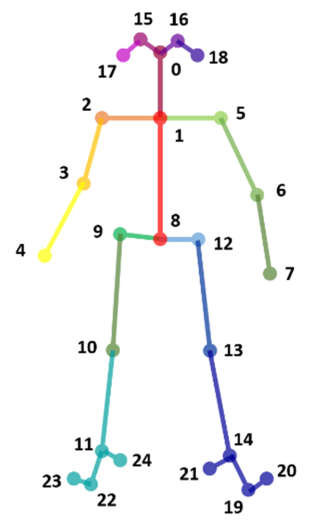

Normalization of keypoint data

In [ ]:
import numpy as np

def normalize_keypoints(all_keypoints):
    normalized_keypoints = []

    for frame in all_keypoints:
        # Find the mid-hip keypoint and extract its (x, y) coordinates
        mid_hip = next((kp[1] for kp in frame if kp[0] == "MidHip"), None)

        # Proceed only if the Mi  dHip keypoint was found
        if mid_hip is not None:
            normalized_frame = []
            for label, (x, y, c) in frame:
                # Normalize the (x, y) coordinates based on the mid-hip
                x_norm = x - mid_hip[0]
                y_norm = y - mid_hip[1]
                normalized_frame.append((label, (x_norm, y_norm, c)))
            normalized_keypoints.append(normalized_frame)

    return normalized_keypoints

def scale_keypoints_for_deadlift(normalized_keypoints):
    scaled_keypoints = []

    for frame in normalized_keypoints:
        mid_hip = np.array([kp[1] for kp in frame if kp[0] == "MidHip"][0])
        ankle = np.array([kp[1] for kp in frame if kp[0] == "RAnkle" or kp[0] == "LAnkle"][0])  # Assuming you take one or average both ankles
        shoulder = np.array([kp[1] for kp in frame if kp[0] == "RShoulder" or kp[0] == "LShoulder"][0])  # Same for shoulders

        # Calculate the scale factor as a combination of leg length and torso length
        leg_length = np.linalg.norm(ankle - mid_hip)
        torso_length = np.linalg.norm(shoulder - mid_hip)
        scale_factor = (leg_length + torso_length) / 2  # This is a simplistic combination; adjust as needed

        scaled_frame = []
        for label, (x, y, c) in frame:
            x, y = np.nan_to_num(x), np.nan_to_num(y)
            x_scaled = x / scale_factor if scale_factor != 0 else 0
            y_scaled = y / scale_factor if scale_factor != 0 else 0
            scaled_frame.append((label, (x_scaled, y_scaled, c)))

        scaled_keypoints.append(scaled_frame)

    return scaled_keypoints

def print_sample_keypoints(original_keypoints, normalized_keypoints, scaled_keypoints, frame_index=0):
    # Print original keypoints for comparison
    print("Original Keypoints (Frame {}):".format(frame_index))
    for label, (x, y, c) in original_keypoints[frame_index]:
        if label in ["MidHip", "Neck"]:
            print(f"{label}: x={x}, y={y}, c={c}")

    # Print normalized keypoints
    print("\nNormalized Keypoints (Frame {}):".format(frame_index))
    for label, (x, y, c) in normalized_keypoints[frame_index]:
        if label in ["MidHip", "Neck"]:
            print(f"{label}: x={x:.2f}, y={y:.2f}, c={c}")

    # Print scaled keypoints
    print("\nScaled Keypoints (Frame {}):".format(frame_index))
    for label, (x, y, c) in scaled_keypoints[frame_index]:
        if label in ["MidHip", "Neck"]:
            print(f"{label}: x={x:.2f}, y={y:.2f}, c={c}")

# Apply the normalization and scaling functions
normalized_notmoving_keypoints = normalize_keypoints(notmoving_keypoints)
scaled_notmoving_keypoints = scale_keypoints_for_deadlift(normalized_notmoving_keypoints)

normalized_bad_keypoints = normalize_keypoints(bad_keypoints)
scaled_bad_keypoints = scale_keypoints_for_deadlift(normalized_bad_keypoints)

normalized_good_keypoints = normalize_keypoints(good_keypoints)
scaled_good_keypoints = scale_keypoints_for_deadlift(normalized_good_keypoints)

normalized_trainer_keypoints = normalize_keypoints(trainer_keypoints)
scaled_trainer_keypoints = scale_keypoints_for_deadlift(normalized_trainer_keypoints)

normalized_trainee_keypoints = normalize_keypoints(trainee_keypoints)
scaled_trainee_keypoints = scale_keypoints_for_deadlift(normalized_trainee_keypoints)

#Test output
frame_index = 15  # For example, to inspect the 16th frame (indexing starts from 0)
print(scaled_trainee_keypoints)

[[('Nose', (0.0461541316264608, -1.0216646710038597, 0.937836)), ('Neck', (0.022763669945478703, -0.6655005185707531, 0.890799)), ('RShoulder', (-0.2299798461295663, -0.6769233586103013, 0.845809)), ('RElbow', (-0.32119854617871574, -0.3438567745238294, 0.858349)), ('RWrist', (-0.321737469913915, -0.02253521314468765, 0.931943)), ('LShoulder', (0.24085790456722816, -0.6655473815042487, 0.85176)), ('LElbow', (0.3331075891532803, -0.34378062225689887, 0.819998)), ('LWrist', (0.3331075891532803, -0.022634796878365736, 0.878274)), ('MidHip', (0.0, 0.0, 0.711542)), ('RHip', (-0.14973293038506996, -1.1715733373951323e-05, 0.752787)), ('RKnee', (-0.2293179071939412, 0.6315834704533264, 0.833114)), ('RAnkle', (-0.2412679552353146, 1.2622238243700534, 0.849889)), ('LHip', (0.14936974265047914, -4.100506680866314e-05, 0.730809)), ('LKnee', (0.22891371439254188, 0.631413592319405, 0.838965)), ('LAnkle', (0.2413441075022448, 1.262569438504584, 0.783654)), ('REye', (0.011159236038635358, -1.0897565

In [ ]:
!pip install fastdtw

**Calculate score**

In [ ]:
from scipy.spatial.distance import euclidean
from fastdtw import fastdtw
import numpy as np

def calculate_range_of_motion(scaled_keypoints, keypoint_index, movement_threshold=0.1):
    # Extract the y-coordinates for the keypoint of interest across all frames
    y_coordinates = np.array([frame[keypoint_index][1][1] for frame in scaled_keypoints if frame[keypoint_index][1][1] > 0])

    # Skip the calculation if there are too few keypoints to analyze
    if len(y_coordinates) < 2:
        return 0

    # Calculate the standard deviation and mean
    std_dev = np.std(y_coordinates)
    mean_y = np.mean(y_coordinates)

    # Filter out values that are more than 2 standard deviations from the mean
    filtered_y = y_coordinates[(y_coordinates > mean_y - 2 * std_dev) & (y_coordinates < mean_y + 2 * std_dev)]

    # Calculate the range of motion
    rom = np.abs(np.max(filtered_y) - np.min(filtered_y))

    # Check if the range of motion exceeds the movement threshold
    # If it doesn't exceed the threshold, consider it as no significant motion
    if rom < movement_threshold:
        return 0
    else:
        return rom


def get_dynamic_score(trainee_range, benchmarks):
    # Define the benchmark thresholds and their corresponding scores
    benchmark_thresholds = [('NotMoving', 0), ('Bad', 20), ('Good', 50), ('Trainer', 76)]
    benchmark_ranges = sorted([(benchmarks[label], score) for label, score in benchmark_thresholds], key=lambda x: x[0])

    print(f"Benchmark Ranges: {benchmark_ranges}")

    # Initialize variables to hold the closest lower and upper benchmarks
    lower_bound = (0, 0)  # Tuple of (range, score)
    upper_bound = (benchmark_ranges[-1][0], 100)  # Assume the uppermost benchmark is the highest possible score

    # Find the closest lower and upper benchmarks
    for range_value, score in benchmark_ranges:
        if trainee_range > range_value:
            lower_bound = (range_value, score)
        elif trainee_range == range_value:
            print(f"Exact match with a benchmark. Trainee Range: {trainee_range}, Score: {score}")
            return score
        else:
            upper_bound = (range_value, score)
            break

    # Calculate the score as a percentage within the lower and upper bounds
    if upper_bound[0] != lower_bound[0]:  # Prevent division by zero
        score_percentage = (trainee_range - lower_bound[0]) / (upper_bound[0] - lower_bound[0])
        dynamic_score = lower_bound[1] + score_percentage * (upper_bound[1] - lower_bound[1])
    else:
        dynamic_score = lower_bound[1]

    print(f"Trainee Range: {trainee_range}")
    print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
    print(f"Dynamic Score: {dynamic_score}")

    return dynamic_score

def calculate_benchmark_ranges(keypoints_sets, keypoint_indices, weights=None):
    benchmarks = {}
    for label, keypoints in keypoints_sets.items():
        # Calculate the range of motion for each keypoint
        ranges = [calculate_range_of_motion(keypoints, idx) for idx in keypoint_indices]

        # Apply weights if provided
        if weights:
            weighted_ranges = np.average(ranges, weights=weights)
        else:
            weighted_ranges = np.mean(ranges)

        benchmarks[label] = weighted_ranges if ranges else 0
    return benchmarks


def main_evaluation(keypoints, benchmarks, category_name):
    keypoint_indices = [1, 2, 3, 4, 5, 6, 7]
    motion_range = np.mean([calculate_range_of_motion(keypoints, idx) for idx in keypoint_indices])
    score = get_dynamic_score(motion_range, benchmarks)
    print(f"{category_name} Deadlift Score: {score:.2f}%")


keypoints_sets = {
    'NotMoving': scaled_notmoving_keypoints,
    'Bad': scaled_bad_keypoints,
    'Good': scaled_good_keypoints,
    'Trainer': scaled_trainer_keypoints
}

keypoint_weights = {
    'neck': 0.25,  # Highest importance for vertical movement
    'rshoulder': 0.15, 'lshoulder': 0.15,  # High importance for vertical movement
    'relbow': 0.10, 'lelbow': 0.10,  # High importance for vertical movement
    'rwrist': 0.10, 'lwrist': 0.10,  # High importance for vertical movement
    'midhip': 0.05,  # Lower importance due to minimal vertical movement
    'rknee': 0, 'lknee': 0,  # Minimal to no importance for vertical movement
    'rankle': 0, 'lankle': 0  # Minimal to no importance for vertical movement
}

weights_list = [
    keypoint_weights['neck'],
    keypoint_weights['rshoulder'],
    keypoint_weights['relbow'],
    keypoint_weights['rwrist'],
    keypoint_weights['lshoulder'],
    keypoint_weights['lelbow'],
    keypoint_weights['lwrist'],
    keypoint_weights['midhip'],
    keypoint_weights['rknee'],
    keypoint_weights['rankle'],
    keypoint_weights['lknee'],
    keypoint_weights['lankle'],
]

# Hardcoded benchmark thresholds
BENCHMARK_THRESHOLDS = {
    'NotMoving': 0.006864331583172799,
    'Bad': 0.04149337486280714,
    'Good': 0.053520071700991954,
    'Trainer': 0.2121902540130363
}

# Normalize the weights so they sum to 1, if necessary
weights_sum = sum(weights_list)
normalized_weights = [w / weights_sum for w in weights_list]

benchmarks = calculate_benchmark_ranges(keypoints_sets, [1, 2, 3, 4, 5, 6, 7]) #uncomment if needed to calculate better ranges
#benchmarks = BENCHMARK_THRESHOLDS  #hardcoded according to current config

# Calculate the trainee's average range of motion using their keypoints
trainee_ranges = [calculate_range_of_motion(scaled_trainee_keypoints, idx) for idx in range(len(scaled_trainee_keypoints[0]))]
trainee_average_range = np.mean(trainee_ranges)

# Get the trainee's score by comparing their average range to the benchmarks
trainee_score = get_dynamic_score(trainee_average_range, benchmarks)

# Print or return the trainee's score
print(f"Trainee Deadlift Score: {trainee_score:.2f}%")

Benchmark Ranges: [(0.0, 0), (0.03555831152335536, 20), (0.05114811214760646, 50), (0.2642660918183917, 76)]
Trainee Range: 0.1491603688159415
Lower Bound: (0.05114811214760646, 50), Upper Bound: (0.2642660918183917, 76)
Dynamic Score: 61.957314335060964
Trainee Deadlift Score: 61.96%


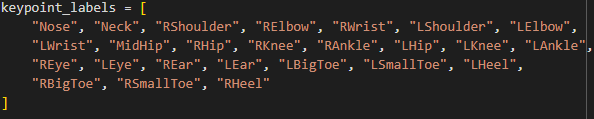

In [ ]:
import glob
import os

# Define the pattern to match the JSON files
pattern = '/content/openpose/output/Deadlift_*_keypoints.json'

# Use glob to find all files matching the pattern
json_files = glob.glob(pattern)

# Check if any files are found and print them
if json_files:
    print(f"Found {len(json_files)} files:")
    for file_path in json_files:
        print(file_path)
else:
    print("No files found. Check your pattern and file path.")

# Loop through each matching file and delete it
for file_path in json_files:
    # Use os.remove() to delete the file
    os.remove(file_path)
    print(f"Deleted {file_path}")

# Confirm completion
print("Completed deleting JSON files.")



Streaming output truncated to the last 5000 lines.
/content/openpose/output/Deadlift_Trainer_resized_000000000438_keypoints.json
/content/openpose/output/Deadlift_NotMoving_resized_000000000267_keypoints.json
/content/openpose/output/Deadlift_Trainee_resized_000000000156_keypoints.json
/content/openpose/output/Deadlift_Trainer_resized_000000000063_keypoints.json
/content/openpose/output/Deadlift_Good_resized_000000000548_keypoints.json
/content/openpose/output/Deadlift_Trainer_resized_000000000476_keypoints.json
/content/openpose/output/Deadlift_Trainer_resized_000000000199_keypoints.json
/content/openpose/output/Deadlift_Trainer_resized_000000000102_keypoints.json
/content/openpose/output/Deadlift_Bad_resized_000000000027_keypoints.json
/content/openpose/output/Deadlift_Trainer_resized_000000000350_keypoints.json
/content/openpose/output/Deadlift_Bad_resized_000000000399_keypoints.json
/content/openpose/output/Deadlift_NotMoving_resized_000000000133_keypoints.json
/content/openpose/ou

**Generate feedback**

In [ ]:
def generate_feedback(score):
    # Define feedback messages for each score range
    feedback_messages = {
        (0, 0): "It looks like you're not moving much. Ensure you're ready to perform the deadlift and try again.",
        (1, 50.8): "Needs Improvement. Focus on maintaining a straight back and driving through your heels.",
        (50.9, 60): "Good job! You're doing well, but there's still room for refinement. Check your posture, as well as your hip and shoulder alignment.",
        (61, 100): "Excellent! You've mastered the trainer's technique."
    }

    # Find the appropriate feedback message based on the score
    for score_range, message in feedback_messages.items():
        if score_range[0] <= score <= score_range[1]:
            return message

    # Fallback message if score doesn't fit any range (shouldn't normally happen)
    return "Feedback not available for your score. Please try again."

# Example usage
score = trainee_score
feedback = generate_feedback(score)
print(feedback)

# This feedback string can then be provided to the middleware,
# along with the URL or path to the trainer's skeleton video, for delivery to the mobile app.


Excellent! You've mastered the trainer's technique.


**Write feedback to JSON**

In [ ]:
import json

def write_feedback_to_json(score, feedback, file_path, video_filename=None):
    # Create a dictionary to hold the score, feedback, and optionally a video filename
    feedback_data = {
        'score': trainee_score,
        'feedback': feedback
    }

    # If a video filename is provided, include it in the feedback data
    if video_filename:
        feedback_data['video_filename'] = video_filename

    # Serialize the dictionary to JSON and write it to a file
    with open(file_path, 'w') as json_file:
        json.dump(feedback_data, json_file, indent=4)

# Example usage
score = 75  # This is the calculated score
feedback = generate_feedback(trainee_score)  # Generates the feedback message based on the score
video_filename = "Deadlift_Trainee_withpose.mp4"  # Filename of the trainer's skeleton video

# Specify the path where you want to save the JSON file
file_path = 'feedback.json'
write_feedback_to_json(score, feedback, file_path, video_filename)

print(f"Feedback and video filename written to {file_path}")


Feedback and video filename written to feedback.json
